## Carregando os dados

In [24]:
#from google.colab import drive
#drive.mount('/content/drive')

# importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.plotting import scatter_matrix

#importando o arquivo
df = pd.read_csv('Base_Treinamento.csv', sep=',')
df.head()


,id,data_criacao,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,BCS-00163074,2026-02-22 10:34:58.338000+00:00,Outros Problemas com Postes,51,Não,Não,Sim,ALTA
1,BCS-00172400,2026-03-07 09:40:54.637000+00:00,Outros Problemas com Postes,38,Não,Não,Sim,ALTA
2,BCS-00166754,2026-02-25 09:02:46.448000+00:00,Luz Queimada Poste,48,Não,Sim,Não,ALTA
3,BCS-00171257,2026-03-04 23:15:53.768443+00:00,Luz Queimada Poste,41,Não,Não,Sim,ALTA
4,BCS-00065327,2025-08-01 06:35:06.539000+00:00,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE


## Pré-processamento: eliminação de atributos irrelevantes

In [25]:
# remove as colunas id e data_criacao
df = df.drop(columns=['id','data_criacao'])

# imprime o dataframe
display(df)

,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,Outros Problemas com Postes,51,Não,Não,Sim,ALTA
1,Outros Problemas com Postes,38,Não,Não,Sim,ALTA
2,Luz Queimada Poste,48,Não,Sim,Não,ALTA
3,Luz Queimada Poste,41,Não,Não,Sim,ALTA
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
...,...,...,...,...,...,...
8634,Luz Queimada,2,Sim,Sim,Não,URGENTE
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA
8636,Problema com Animal Doméstico,91,Sim,Sim,Sim,URGENTE
8637,Problema com Animal Doméstico,7,Não,Não,Não,BAIXA


Retirados os atributos id e data_criacao:

id -> Desnecessário para análise;
data_criacao -> Refeleta data de criação do chamdo, não tem relação com o atributo dias_problemas, e não deve serc onsiderado na análise, pois o chamado deve ser classificado no mesmo dia, não interferindo esse campo na classe urgencia;

Mantidos os campos:

dias_problemas -> O usuário informará quantos dias que fazem que o problema relatado no chamado existe, não necessáriamente é no mesmo dia da abertura do chamdo, pode ser antes; (Atributo contínuo)
risco_vida_humana -> Atributo descritivo, podendo ser Sim ou Não
risco_vida_animal -> Atributo descritivo, podendo ser Sim ou Não
bloqueio_via -> Atributo descritivo, podendo ser Sim ou Não

urgencia -> classe descritiva (URGENTE, ALTA, MEDIA, BAIXA)

## Pré-processamento: tratamento de atributos com valores ausentes

In [19]:
# índices das linhas que contém valores NaN
idxRowNan = pd.isnull(df).any(axis=1).to_numpy().nonzero()

# imprime apenas as linhas com valoes ausentes
display(df.iloc[idxRowNan])

,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia


Nenhum atributo ausente encontrado

In [20]:
'''
def trataFaltantes(df):
    #Substitui os valores faltantes pela média dos outros valores do mesmo atributo
    #de amostras que sejam da mesma classe

    # seleciona apenas as linhas da base de dados onde a coluna largura_sepala não contém valores nulos
    notNull_ls = df.loc[ ~pd.isnull(df['largura_sepala']), :]
    notNull_cp = df.loc[ ~pd.isnull(df['comprimento_petala']), :]

    # calcula a media dos valores do atributo largura_sepala que não são nulos e que são da classe Iris-setosa
    media_ls = notNull_ls[ notNull_ls['classe']=='Iris-setosa' ]['largura_sepala'].mean()
    media_cp = notNull_cp[ notNull_cp['classe']=='Iris-setosa' ]['comprimento_petala'].mean()

    # substitui os valores nulos pela média
    df.loc[ pd.isnull(df['largura_sepala']), 'largura_sepala'] = media_ls
    df.loc[ pd.isnull(df['comprimento_petala']), 'comprimento_petala'] = media_cp

    return df

trataFaltantes(df)

# imprime apenas as linhas que antes possuiam valores NaN
print('\nAmostras que possuiam valores faltantes:')
display(df.iloc[idxRowNan])
'''

"\ndef trataFaltantes(df):\n    #Substitui os valores faltantes pela média dos outros valores do mesmo atributo\n    #de amostras que sejam da mesma classe\n\n    # seleciona apenas as linhas da base de dados onde a coluna largura_sepala não contém valores nulos\n    notNull_ls = df.loc[ ~pd.isnull(df['largura_sepala']), :]\n    notNull_cp = df.loc[ ~pd.isnull(df['comprimento_petala']), :]\n\n    # calcula a media dos valores do atributo largura_sepala que não são nulos e que são da classe Iris-setosa\n    media_ls = notNull_ls[ notNull_ls['classe']=='Iris-setosa' ]['largura_sepala'].mean()\n    media_cp = notNull_cp[ notNull_cp['classe']=='Iris-setosa' ]['comprimento_petala'].mean()\n\n    # substitui os valores nulos pela média\n    df.loc[ pd.isnull(df['largura_sepala']), 'largura_sepala'] = media_ls\n    df.loc[ pd.isnull(df['comprimento_petala']), 'comprimento_petala'] = media_cp\n\n    return df\n\ntrataFaltantes(df)\n\n# imprime apenas as linhas que antes possuiam valores NaN\np

Não necessária essa faze, pois não foram encontrados valores ausentes

## Pré-processamento: tratamento de dados inconsistentes ou redundantes

In [21]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana', 'risco_vida_animal','bloqueio_via'],keep=False)]

# se houver valores redundantes ou inconsistentes, imprima
if len(df_duplicates)>0:
    print('\nAmostras redundantes ou inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores duplicados')


Amostras redundantes ou inconsistentes:


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
2,Luz Queimada Poste,48,Não,Sim,Não,ALTA
3,Luz Queimada Poste,41,Não,Não,Sim,ALTA
5,Problema com Animal Doméstico,256,Sim,Não,Sim,URGENTE
6,Problema com Animal Selvagem,256,Sim,Sim,Sim,URGENTE
7,Problema com Animal Selvagem,256,Não,Não,Sim,ALTA
...,...,...,...,...,...,...
8632,Manutenção da Área Verde,2,Não,Sim,Não,MEDIA
8633,Manutenção da Área Verde,2,Não,Não,Não,BAIXA
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA
8636,Problema com Animal Doméstico,91,Sim,Sim,Sim,URGENTE


In [23]:
def delDuplicatas(df):
   '''
   Para cada grupo de amostras duplicadas, mantém uma e apaga as demais
   '''

   # remove as amostras duplicadas, mantendo apenas a primeira ocorrencia
   df = df.drop_duplicates(keep = 'first')

   return df

df = delDuplicatas(df)

display(df)


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
0,Outros Problemas com Postes,51,Não,Não,Sim,ALTA
1,Outros Problemas com Postes,38,Não,Não,Sim,ALTA
2,Luz Queimada Poste,48,Não,Sim,Não,ALTA
3,Luz Queimada Poste,41,Não,Não,Sim,ALTA
4,Problema com Animal Doméstico,256,Sim,Não,Não,URGENTE
...,...,...,...,...,...,...
8627,Animal Morto no Parque/Praça,4,Não,Sim,Não,MEDIA
8628,Manutenção da Área Verde,4,Sim,Não,Não,URGENTE
8630,Lixo e Detritos,4,Não,Não,Sim,MEDIA
8634,Luz Queimada,2,Sim,Sim,Não,URGENTE


Removidas linhas redundantes, no total de 3228 linhas redundantes removidas

In [27]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

# para detectar inconsistências, a rotina abaixo obtém as amostras onde os valores
# dos atributos continuam duplicados. Neste caso, os atributos serão iguais, mas as classes serão distintas
df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'],keep=False)]

# se tiver valores inconsistentes, imprime
if len(df_duplicates)>0:
   print('\nAmostras inconsistentes:')
   display(df_duplicates)
else:
   print('Não existem mostras inconsistentes')



Amostras inconsistentes:


,tipo_chamado,dias_problema,risco_vida_humana,risco_vida_animal,bloqueio_via,urgencia
2,Luz Queimada Poste,48,Não,Sim,Não,ALTA
3,Luz Queimada Poste,41,Não,Não,Sim,ALTA
5,Problema com Animal Doméstico,256,Sim,Não,Sim,URGENTE
6,Problema com Animal Selvagem,256,Sim,Sim,Sim,URGENTE
7,Problema com Animal Selvagem,256,Não,Não,Sim,ALTA
...,...,...,...,...,...,...
8632,Manutenção da Área Verde,2,Não,Sim,Não,MEDIA
8633,Manutenção da Área Verde,2,Não,Não,Não,BAIXA
8635,Lixo e Detritos,1,Não,Sim,Não,MEDIA
8636,Problema com Animal Doméstico,91,Sim,Sim,Sim,URGENTE


In [29]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia

def delInconsistencias(df):
   '''
   Remove todas as amostras inconsistentes da base de dados
   '''

   df = df.drop_duplicates(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'], keep = False)
   return df

df = delInconsistencias(df)

# obtém apenas as amostras onde os valores dos atributos estão duplicados
df_duplicates = df[ df.duplicated(subset=['tipo_chamado','dias_problema','risco_vida_humana','risco_vida_animal', 'bloqueio_via'],keep=False)]

# se tiver valores redundantes ou inconsistentes, imprime
if len(df_duplicates)>0:
   display(df_duplicates)
else:
   print('Não existem amostras redundantes ou inconsistentes')

Não existem amostras redundantes ou inconsistentes


In [30]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes)


,dias_problema
count,3494.000000
mean,101.131082
std,70.062391
min,1.000000
25%,35.000000
50%,95.000000
75%,154.000000
max,256.000000


## Pré-processamento: normalização dos atributos

In [ ]:
def normalizar(X):
   """
   Normaliza os atributos em X

   Esta função retorna uma versao normalizada de X onde o valor da
   média de cada atributo é igual a 0 e desvio padrao é igual a 1. Trata-se de
   um importante passo de pré-processamento quando trabalha-se com
   métodos de aprendizado de máquina.
   """

   m, n = X.shape # m = qtde de objetos e n = qtde de atributos por objeto

   # Incializa as variaves de saída
   X_norm = np.random.rand(m,n) # inicializa X_norm com valores aleatórios
   mu = 0 # inicializa a média
   sigma = 1 # inicializa o desvio padrão

   mu = np.mean(X, axis=0)
   sigma = np.std(X, axis=0, ddof=1)

   for i in range(m):
       X_norm[i,:] = (X[i,:]-mu) / sigma


   return X_norm, mu, sigma

# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia
# reovendo os atributos descritivos e classe da normalização
# coloca os valores dos atributos na variável X
X = df.iloc[:,1:-4].values

# chama a função para normalizar X
X_norm, mu, sigma = normalizar(X)

df.iloc[:,1:-4] = X_norm

print(f"\nMédia: {mu}")
print(f"Desvio padrão: {sigma}")

# Verifique se os dados estão corretos
print(f"\nTotal de amostras: {len(X)}")

print('\nPrimeira amostra da base antes da normalização: [%2.4f].' % X[0,0])
print('\nPrimeira amostra da base após normalização: [%2.4f].' % X_norm[0,0])




Média: [0.]
Desvio padrão: [1.]

Total de amostras: 3494

Primeira amostra da base antes da normalização: [-0.7155].

Primeira amostra da base após normalização: [-0.7155].


Executada a normalização, levando a Média a 0 e o Desvio Padrão a 1.

In [40]:
# apresenta as principais estatísticas da base de dados
df_detalhes = df.describe()

display(df_detalhes.round(8))

,dias_problema
count,3494.000000
mean,0.000000
std,1.000000
min,-1.429170
25%,-0.943888
50%,-0.087509
75%,0.754598
max,2.210443


## Pré-processamento: detecção de *outliers*

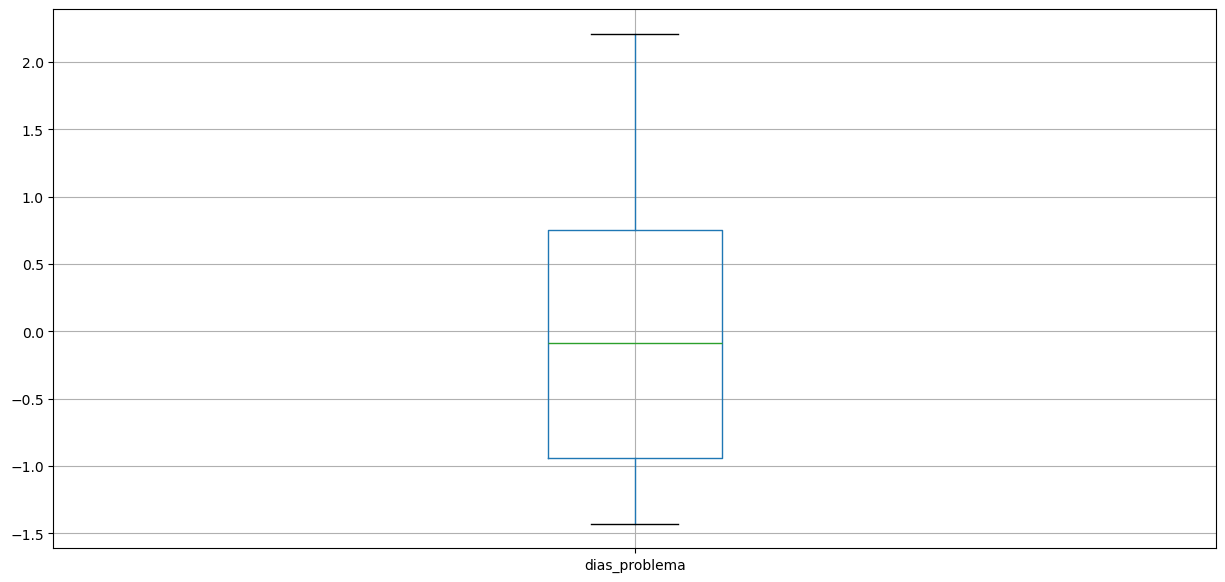

In [41]:
# gera um bloxplot para cada atributo
df.boxplot(figsize=(15,7))
plt.show()


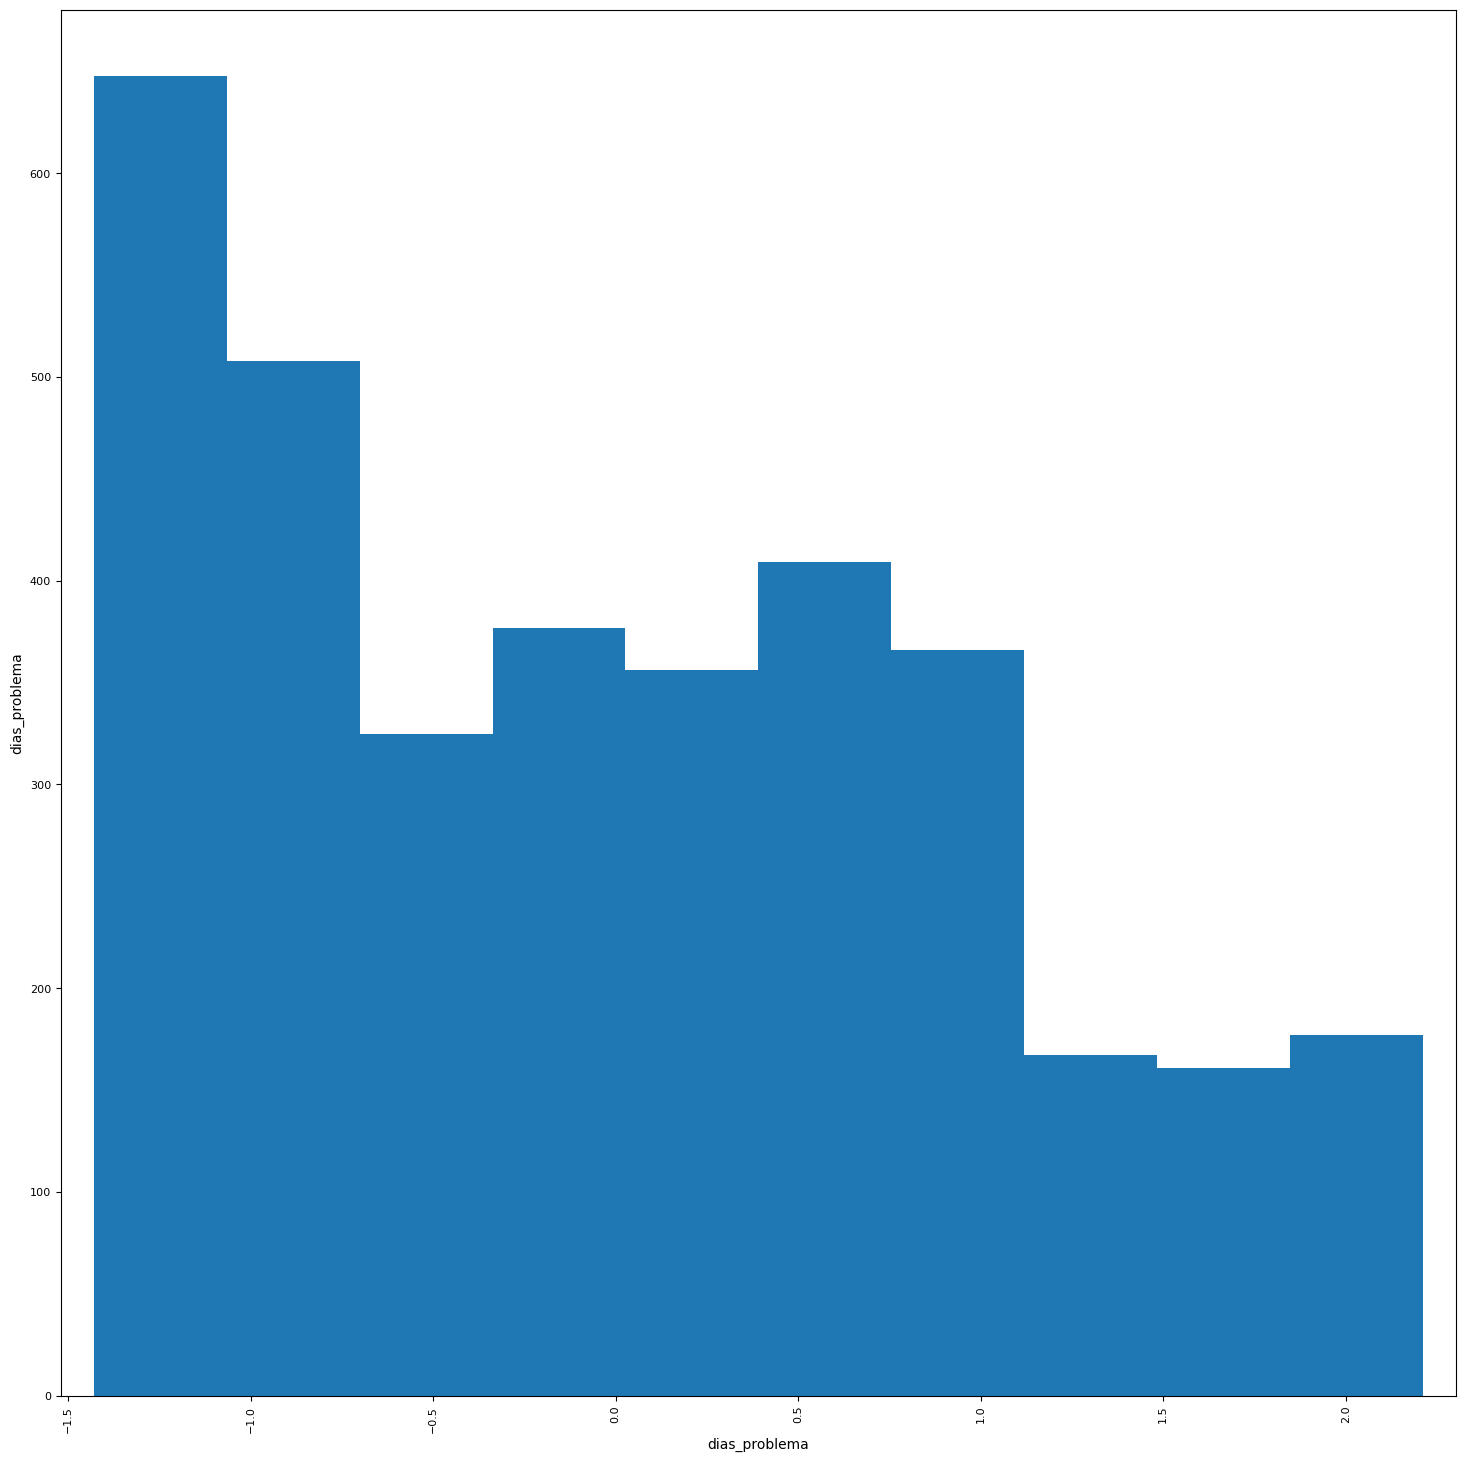

In [42]:
pd.plotting.scatter_matrix(df, figsize=(18,18))
plt.show()


In [47]:
# matriz de gráficos scatter
# sns.pairplot(df, hue='urgencia', height=3.5);

# mostra o gráfico usando a função show() da matplotlib
# plt.show()

# Como não há mais de um atributo numérico, não é possível gerar um gráfico de dispersão. O gráfico de dispersão é utilizado para visualizar a relação entre dois atributos numéricos.

Como não há mais de um atributo numérico, não é possível gerar um gráfico de dispersão. O gráfico de dispersão é utilizado para visualizar a relação entre dois atributos numéricos.

In [48]:
# tipo_chamado	dias_problema	risco_vida_humana	risco_vida_animal	bloqueio_via	urgencia
# define o scatter plot
'''
sns.lmplot(x='tipo_chamado', y='dias_problema', data=df,
          fit_reg=False,
          hue='urgencia')

# cria um título para o gráfico
plt.title('Comprimento vs largura da sepala')

# mostra o gráfico
plt.show()
'''


"\nsns.lmplot(x='tipo_chamado', y='dias_problema', data=df,\n          fit_reg=False,\n          hue='urgencia')\n\n# cria um título para o gráfico\nplt.title('Comprimento vs largura da sepala')\n\n# mostra o gráfico\nplt.show()\n"

Como não há mais de um atributo numérico, não é possível gerar esse gráfico também. E algumas execução abaixo também não poderam ser executadas devido a isso.

In [53]:
'''
for atributo in df.columns[:-1]:
   # define a dimensão do gráfico
   plt.figure(figsize=(8,8))

   # cria o boxplot
   sns.boxplot(x="urgencia", y=atributo, data=df, whis=1.5)

   # mostra o gráfico
   plt.show()
'''

'\nfor atributo in df.columns[:-1]:\n   # define a dimensão do gráfico\n   plt.figure(figsize=(8,8))\n\n   # cria o boxplot\n   sns.boxplot(x="urgencia", y=atributo, data=df, whis=1.5)\n\n   # mostra o gráfico\n   plt.show()\n'

In [55]:
'''

def removeOutliers(df):
   """
   Remove os outliers da base de dados
   """

   for atributo in df.columns[:-1]:

       # obtem o terceiro e o primeiro quartil.
       q75, q25 = np.percentile(df[atributo].values, [75 ,25])

       # calcula o IQR
       IQR = q75 - q25

       # remove os outliers com base no valor do IQR
       df = df[ (df[atributo]<=(q75+1.5*IQR)) & (df[atributo]>=(q25-1.5*IQR)) ]

   return df

# remove os outliers
df = removeOutliers(df)

# apresenta as principais estatísticas sobre a base de dados
df.boxplot(figsize=(15,7))
plt.show()

# matriz de gráficos scatter
sns.pairplot(df, hue='classe', height=3.5);

# mostra o gráfico usando a função show() da matplotlib
plt.show()

'''

'\n\ndef removeOutliers(df):\n   """\n   Remove os outliers da base de dados\n   """\n\n   for atributo in df.columns[:-1]:\n\n       # obtem o terceiro e o primeiro quartil.\n       q75, q25 = np.percentile(df[atributo].values, [75 ,25])\n\n       # calcula o IQR\n       IQR = q75 - q25\n\n       # remove os outliers com base no valor do IQR\n       df = df[ (df[atributo]<=(q75+1.5*IQR)) & (df[atributo]>=(q25-1.5*IQR)) ]\n\n   return df\n\n# remove os outliers\ndf = removeOutliers(df)\n\n# apresenta as principais estatísticas sobre a base de dados\ndf.boxplot(figsize=(15,7))\nplt.show()\n\n# matriz de gráficos scatter\nsns.pairplot(df, hue=\'classe\', height=3.5);\n\n# mostra o gráfico usando a função show() da matplotlib\nplt.show()\n\n'

Como Outliers não doram encontrados, não é necessário remove-los

## Pré-processamento: distribuição das classes

urgencia
URGENTE    2055
ALTA        790
MEDIA       521
BAIXA       128
Name: count, dtype: int64

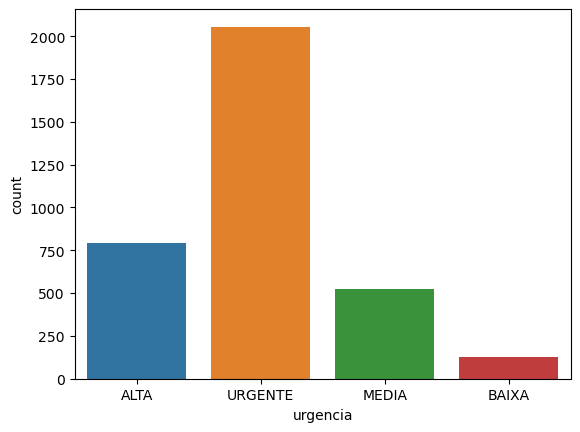

In [58]:
display(df['urgencia'].value_counts())

# cria um gráfico de barras com a frequência de cada urgencia
sns.countplot(x="urgencia", data=df)

# mostra o gráfico
plt.show()

## Pré-processamento: correlação entre os atributos

In [61]:
'''
# criando uma matriz X com os valores do data frame
X = df.iloc[:,:-1].values

# matriz de correlação
correlation = np.corrcoef(X, rowvar=False)

print('\n\nMatriz de correlação: ')
display(correlation)
'''

"\n# criando uma matriz X com os valores do data frame\nX = df.iloc[:,:-1].values\n\n# matriz de correlação\ncorrelation = np.corrcoef(X, rowvar=False)\n\nprint('\n\nMatriz de correlação: ')\ndisplay(correlation)\n"

In [62]:
'''
df_values = df.drop(columns=['urgencia'])

# matriz de correlação
df_correlation = df_values.corr()

print('\n\nMatriz de correlação: ')
display(df_correlation)
'''

"\ndf_values = df.drop(columns=['urgencia'])\n\n# matriz de correlação\ndf_correlation = df_values.corr()\n\nprint('\n\nMatriz de correlação: ')\ndisplay(df_correlation)\n"

In [63]:
'''
# cria um mapa de cores dos valores da correlação
sns.heatmap(df_correlation,
        xticklabels=df_correlation.columns,
        yticklabels=df_correlation.columns)

plt.title('Correlacao')
plt.show()
'''

"\n# cria um mapa de cores dos valores da correlação\nsns.heatmap(df_correlation,\n        xticklabels=df_correlation.columns,\n        yticklabels=df_correlation.columns)\n\nplt.title('Correlacao')\nplt.show()\n"

Como somente um atributo é quantitativo, não é possivel criar uma matriz de correlação deles